In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

churn_df=pd.read_csv(r"C:\Users\tarak\Data Files\CSV\telecom_churn_data.csv")
churn_df.columns

Index(['year', 'customer_id', 'phone_no', 'gender', 'age',
       'no_of_days_subscribed', 'multi_screen', 'mail_subscribed',
       'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive',
       'customer_support_calls', 'churn'],
      dtype='object')

In [2]:
churn_df=churn_df.drop(['year','customer_id','phone_no'],axis=1)
churn_df.columns

Index(['gender', 'age', 'no_of_days_subscribed', 'multi_screen',
       'mail_subscribed', 'weekly_mins_watched', 'minimum_daily_mins',
       'maximum_daily_mins', 'weekly_max_night_mins', 'videos_watched',
       'maximum_days_inactive', 'customer_support_calls', 'churn'],
      dtype='object')

In [3]:
print('\nShape:\n',churn_df.shape)
print('\nsize:\n',churn_df.size)
print('\nhead:\n',churn_df.head())
print('\ntail:\n',churn_df.tail())
print('\ninfo:\n')
churn_df.info()
print('\ndescribe:\n')
churn_df.describe()


Shape:
 (2000, 13)

size:
 26000

head:
    gender  age  no_of_days_subscribed multi_screen mail_subscribed  \
0  Female   36                     62           no              no   
1  Female   39                    149           no              no   
2  Female   65                    126           no              no   
3  Female   24                    131           no             yes   
4  Female   40                    191           no              no   

   weekly_mins_watched  minimum_daily_mins  maximum_daily_mins  \
0               148.35                12.2               16.81   
1               294.45                 7.7               33.37   
2                87.30                11.9                9.89   
3               321.30                 9.5               36.41   
4               243.00                10.9               27.54   

   weekly_max_night_mins  videos_watched  maximum_days_inactive  \
0                     82               1                    4.0   
1     

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1972.000000,2000.000000,1965.000000
mean,38.69050,99.750000,270.178425,10.198700,30.620780,100.415500,4.482500,3.250507,1.547000,0.133333
std,10.20641,39.755386,80.551627,2.785519,9.129165,19.529454,2.487728,0.809084,1.315164,0.340021
min,18.00000,1.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,73.000000,218.212500,8.400000,24.735000,87.000000,3.000000,3.000000,1.000000,0.000000
50%,37.00000,99.000000,269.925000,10.200000,30.590000,101.000000,4.000000,3.000000,1.000000,0.000000
75%,44.00000,127.000000,324.675000,12.000000,36.797500,114.000000,6.000000,4.000000,2.000000,0.000000
max,82.00000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000


In [4]:
cat_cols=churn_df.select_dtypes(include='object').columns.tolist()
num_cols=churn_df.select_dtypes(include='number').columns.tolist()

In [5]:
print('\ncategorical columns\n',cat_cols)
print('\nnumerical columns\n',num_cols)


categorical columns
 ['gender', 'multi_screen', 'mail_subscribed']

numerical columns
 ['age', 'no_of_days_subscribed', 'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins', 'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive', 'customer_support_calls', 'churn']


In [6]:
churn_df.isnull().sum()

gender                    24
age                        0
no_of_days_subscribed      0
multi_screen               0
mail_subscribed            0
weekly_mins_watched        0
minimum_daily_mins         0
maximum_daily_mins         0
weekly_max_night_mins      0
videos_watched             0
maximum_days_inactive     28
customer_support_calls     0
churn                     35
dtype: int64

In [7]:
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy='median')
cat_imputer=SimpleImputer(strategy='most_frequent')
churn_df[num_cols]=num_imputer.fit_transform(churn_df[num_cols])
churn_df[cat_cols]=cat_imputer.fit_transform(churn_df[cat_cols])

In [8]:
churn_df.isnull().sum()

gender                    0
age                       0
no_of_days_subscribed     0
multi_screen              0
mail_subscribed           0
weekly_mins_watched       0
minimum_daily_mins        0
maximum_daily_mins        0
weekly_max_night_mins     0
videos_watched            0
maximum_days_inactive     0
customer_support_calls    0
churn                     0
dtype: int64

In [9]:
churn_df.duplicated().sum()
churn_df=churn_df.drop_duplicates()

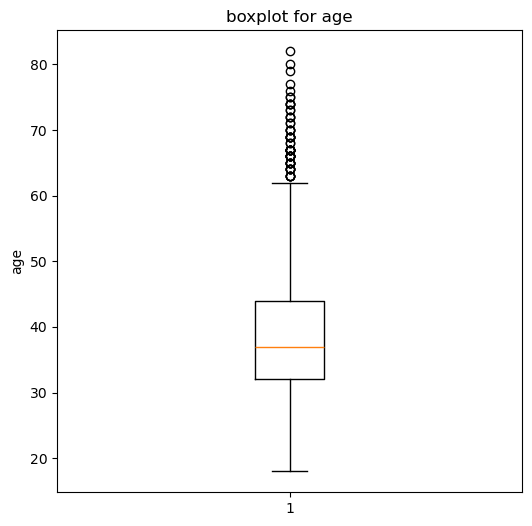

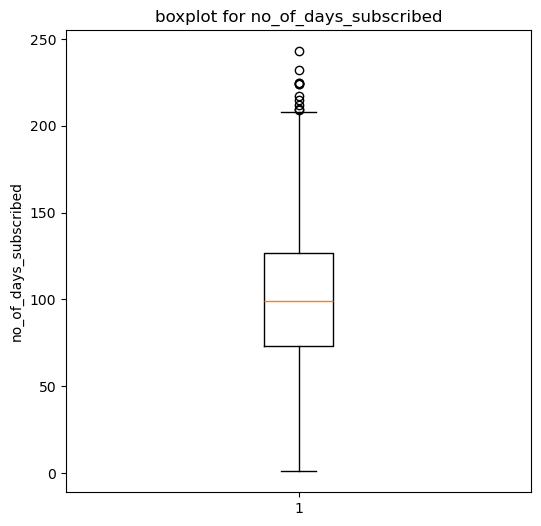

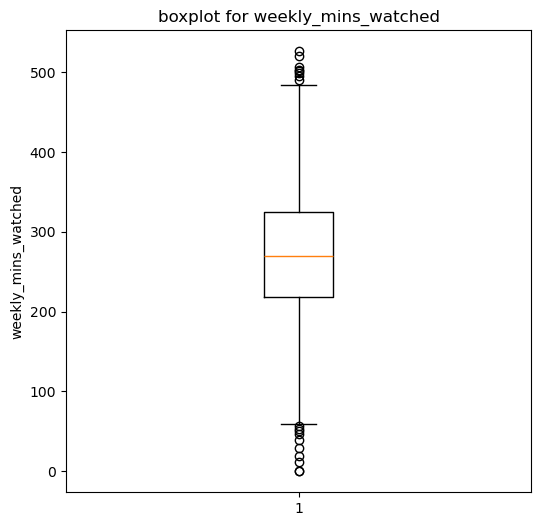

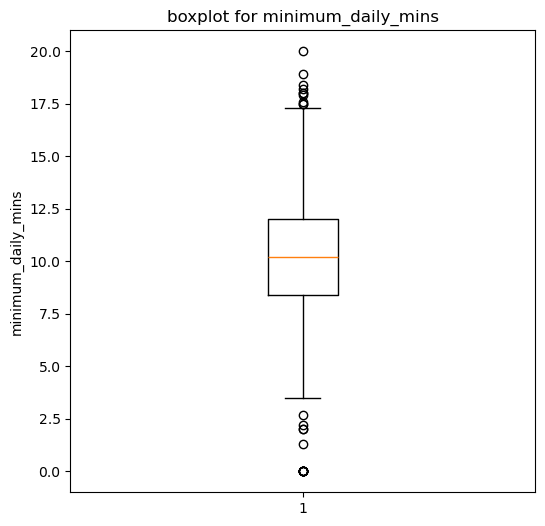

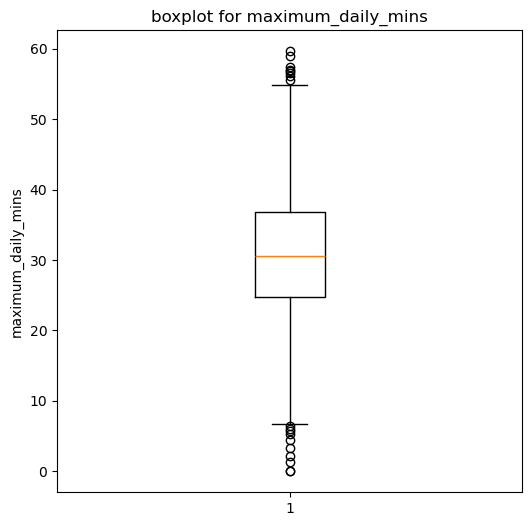

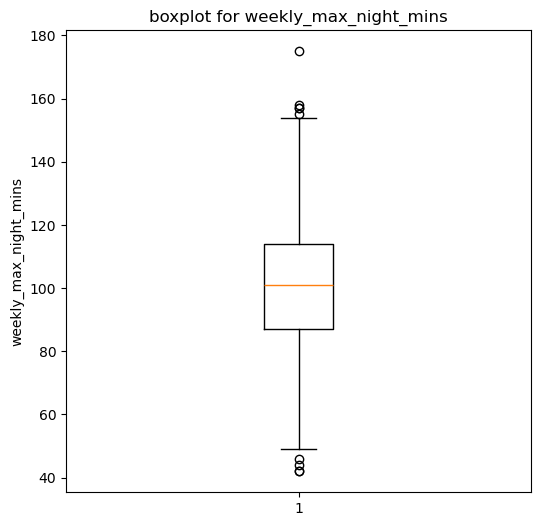

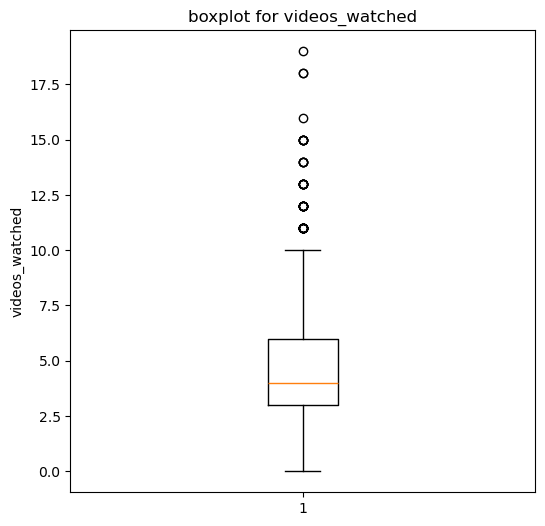

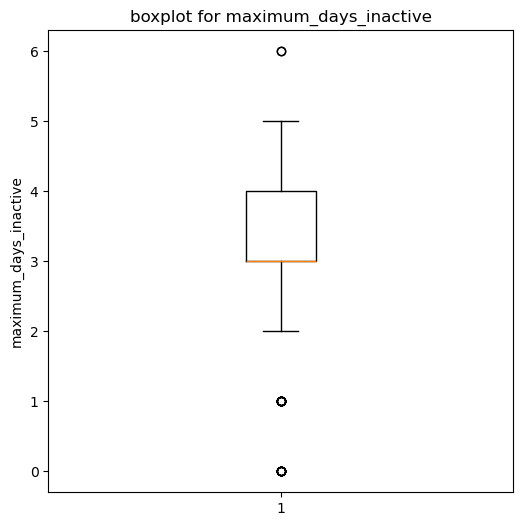

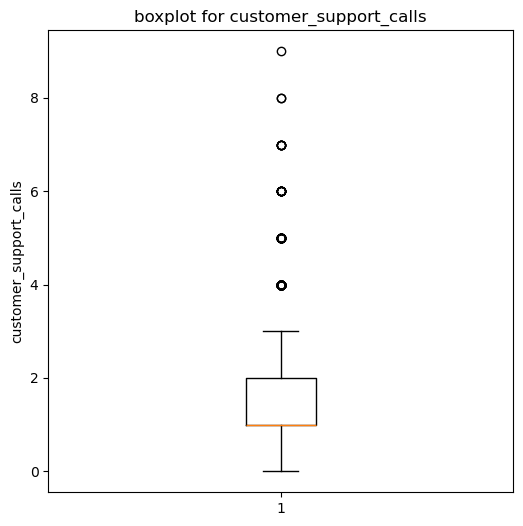

In [10]:
import os
save_folder=r"C:\Users\tarak\Data Files\EDA\Boxplot_before_outlie_analysis"
os.makedirs(save_folder,exist_ok=True)
for i in num_cols:
    if i=='churn':
        continue
    plt.figure(figsize=(6,6))
    plt.boxplot(churn_df[i])
    plt.title(f'boxplot for {i}')
    plt.ylabel(i)
    plt.savefig(os.path.join(save_folder,f'{i}_before.png'))
    plt.show()
    plt.close()

    q1=churn_df[i].quantile(.25)
    q3=churn_df[i].quantile(.75)
    iqr=q3-q1
    lower_limit=q1-1.5*iqr
    upper_limit=q3+1.5*iqr
    outlier=churn_df[(churn_df[i]<lower_limit) | (churn_df[i]>upper_limit)]

    median_value=churn_df[i].median()
    churn_df.loc[(churn_df[i]< lower_limit) | (churn_df[i]>upper_limit),i]=median_value

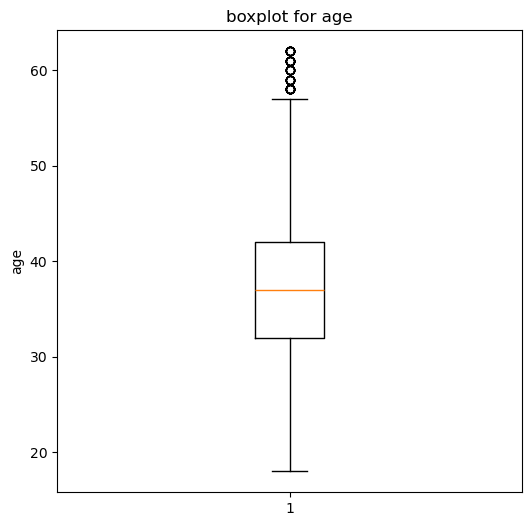

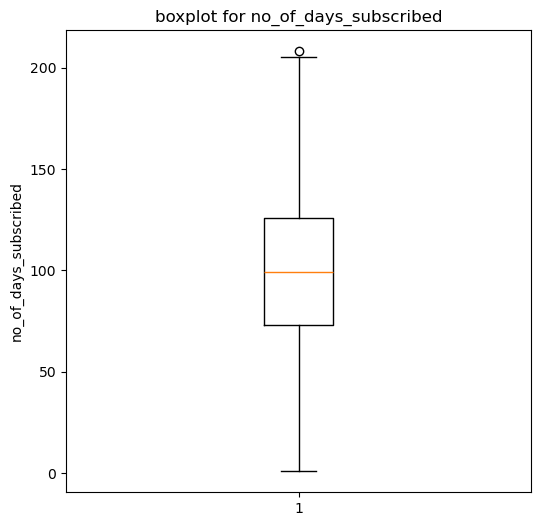

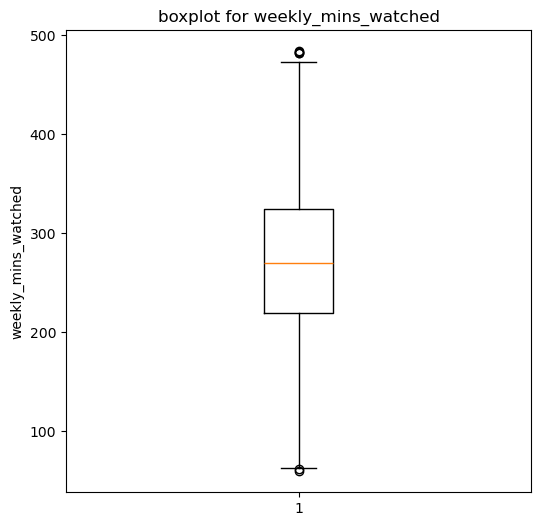

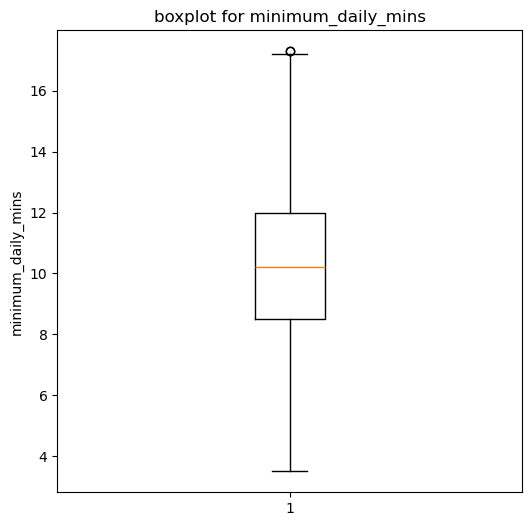

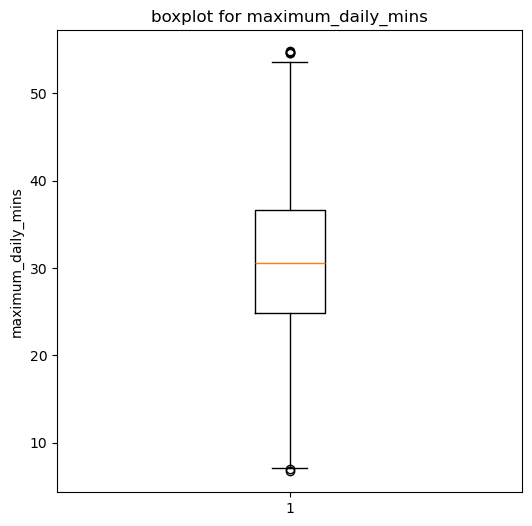

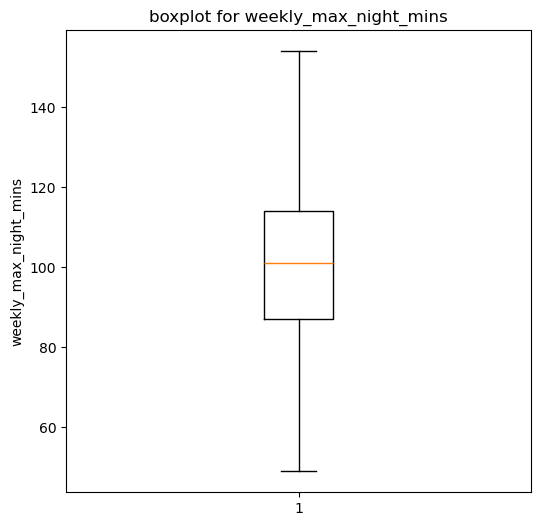

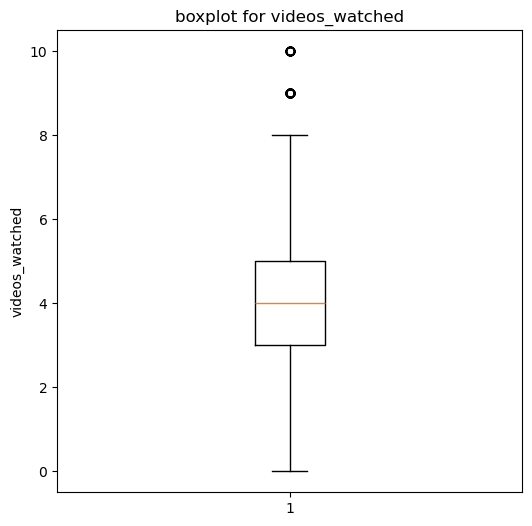

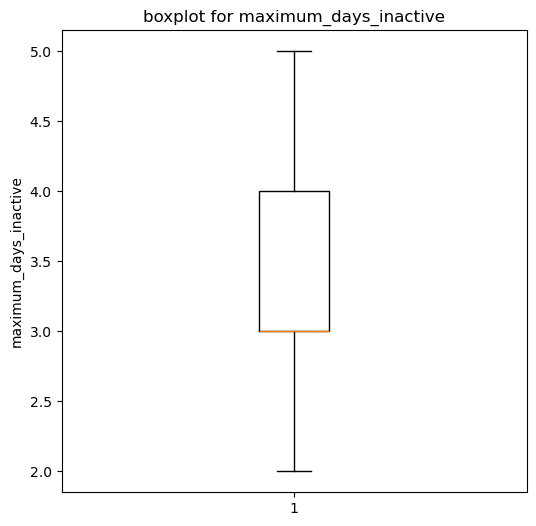

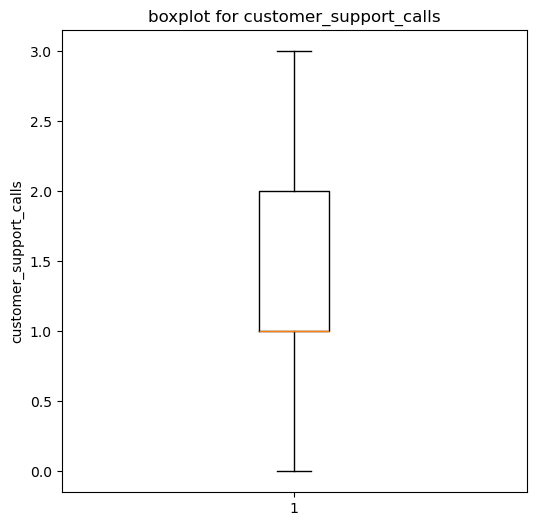

In [11]:
import os 
save_folder=r"C:\Users\tarak\Data Files\EDA\boxplot after outlier analysis"
os.makedirs(save_folder,exist_ok=True)
for i in num_cols:
    if i=='churn':
        continue
    plt.figure(figsize=(6,6))
    plt.boxplot(churn_df[i])
    plt.ylabel(i)
    plt.title(f'boxplot for {i}')
    plt.savefig(os.path.join(save_folder,f'{i}_after.png'))
    plt.show()
    plt.close()

In [12]:
churn_df['churn']=churn_df['churn'].astype('int')

In [13]:
churn_df['churn'].dtypes

dtype('int64')

In [14]:
import os
import pandas as pd

save_folder=r"C:\Users\tarak\Data Files\EDA\Freq & relative freq table"
os.makedirs(save_folder,exist_ok=True)

for i in cat_cols:
    freq_table=pd.DataFrame({'Frequency':churn_df[i].value_counts(),
                             'Relative Frequency':churn_df[i].value_counts(normalize=True)})
    file_path=os.path.join(save_folder,f'{i}_frequency_&_relative_frequency_table.csv')
    freq_table.to_csv(file_path)
    print(freq_table)

        Frequency  Relative Frequency
gender                               
Male         1077              0.5385
Female        923              0.4615
              Frequency  Relative Frequency
multi_screen                               
no                 1802               0.901
yes                 198               0.099
                 Frequency  Relative Frequency
mail_subscribed                               
no                    1430               0.715
yes                    570               0.285


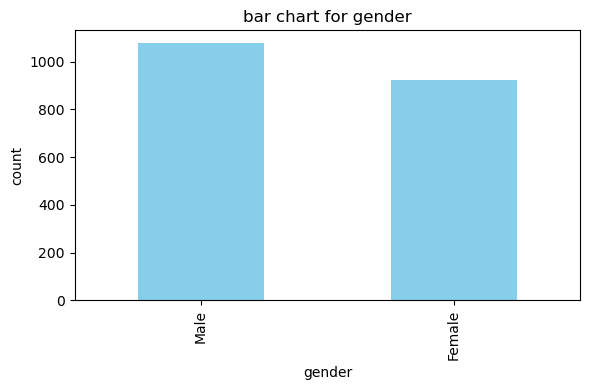

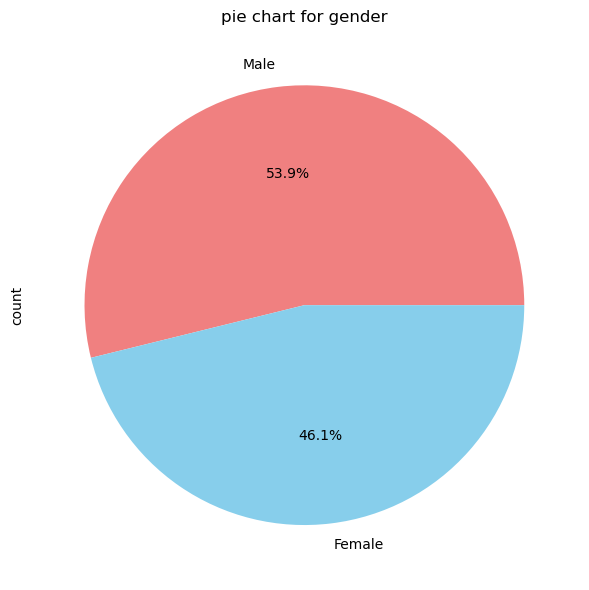

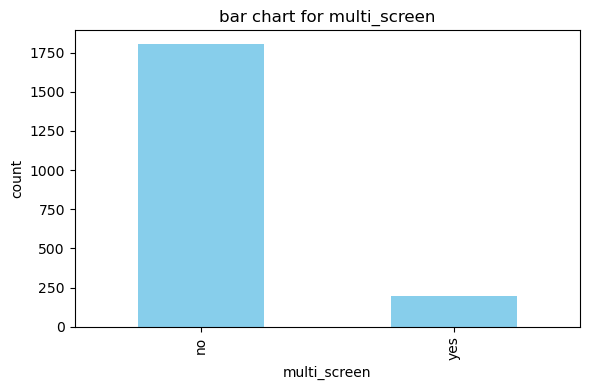

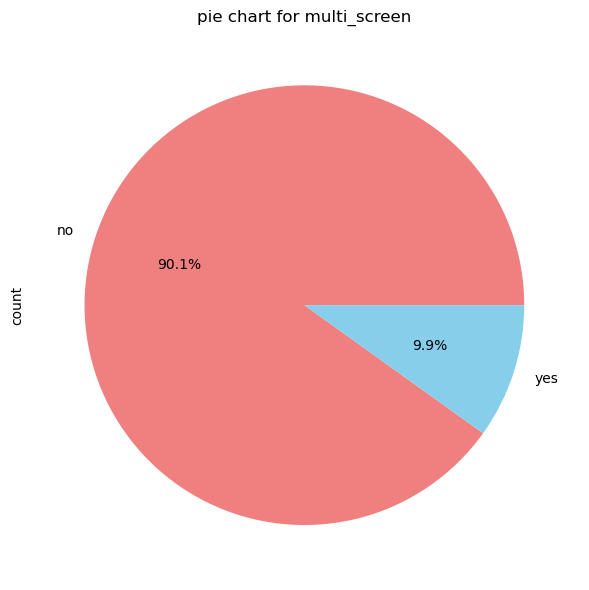

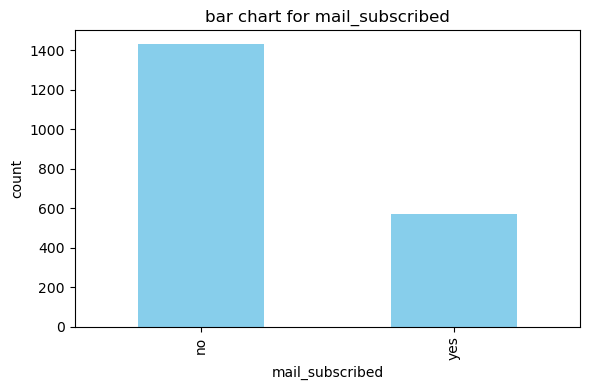

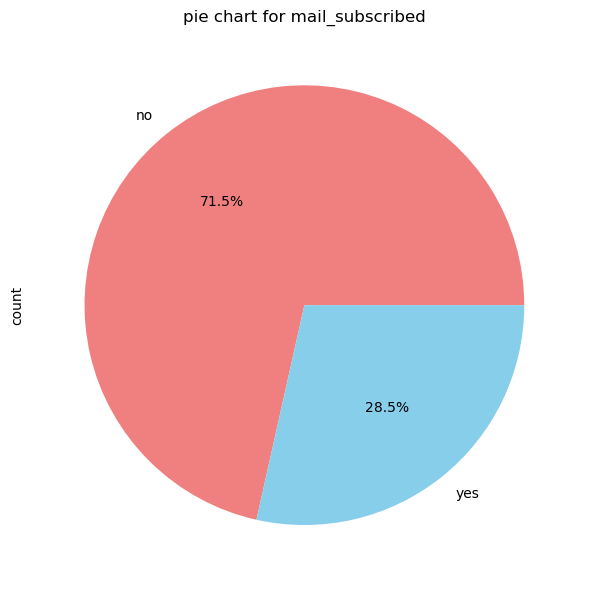

In [15]:
import os
import matplotlib.pyplot as plt

save_folder=r"C:\Users\tarak\Data Files\EDA\bar & pie chart"
os.makedirs(save_folder,exist_ok=True)

for i in cat_cols:
    count=churn_df[i].value_counts()
    plt.figure(figsize=(6,4))
    count.plot(kind='bar',color='skyblue')
    plt.title(f'bar chart for {i}')
    plt.ylabel('count')
    plt.xlabel(i)
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder,f'{i}_bar.png'))
    plt.show()
    plt.close()

    plt.figure(figsize=(6,6))
    count.plot(kind='pie',autopct='%1.1f%%',colors=['lightcoral','skyblue','lightgreen'])
    plt.title(f'pie chart for {i}')
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder,f'{i}_pie.png'))
    plt.show()
    plt.close()

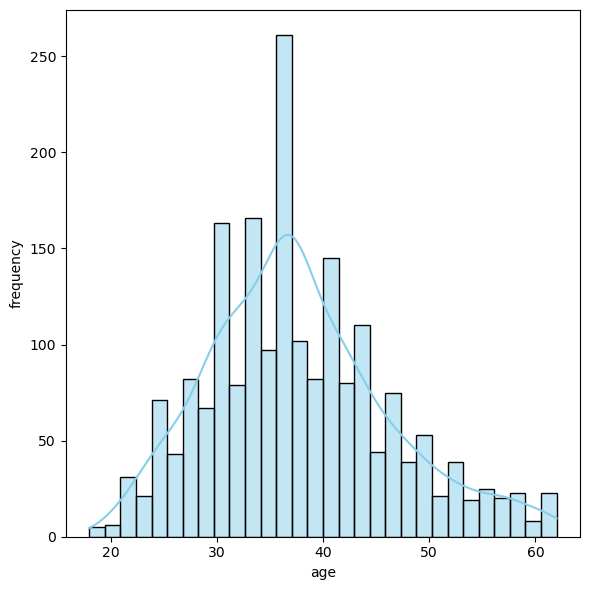

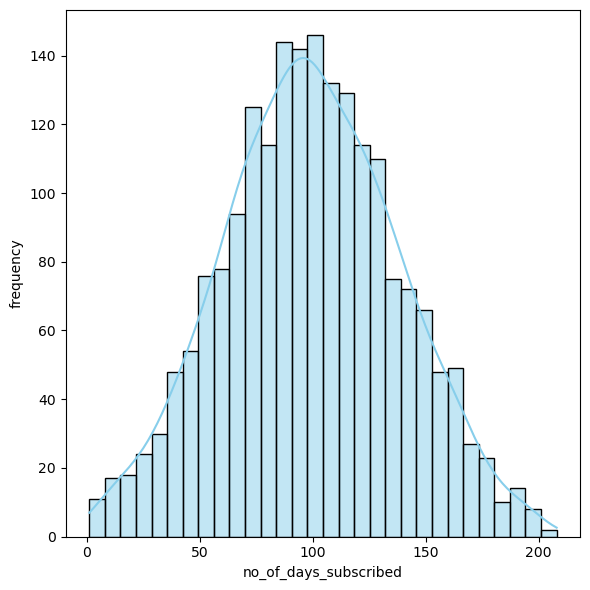

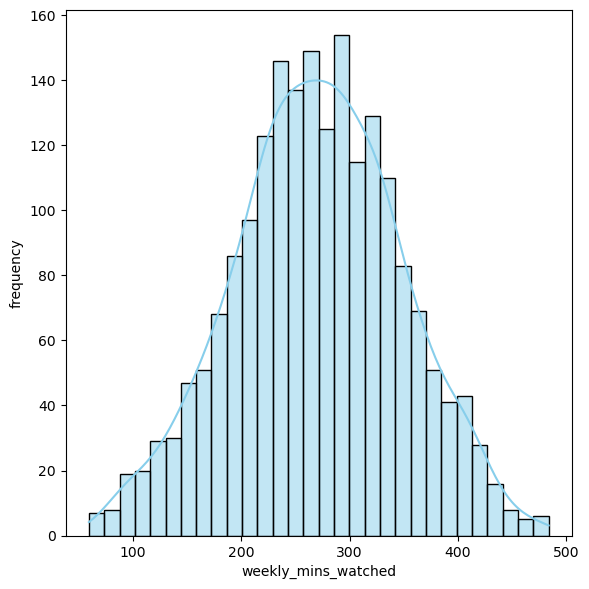

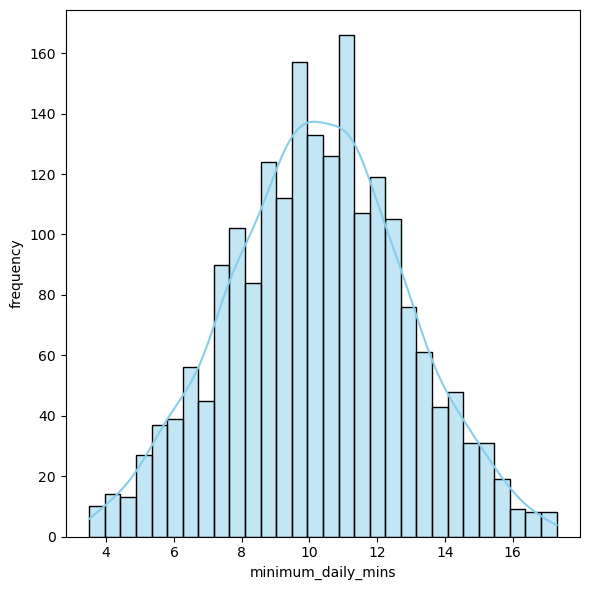

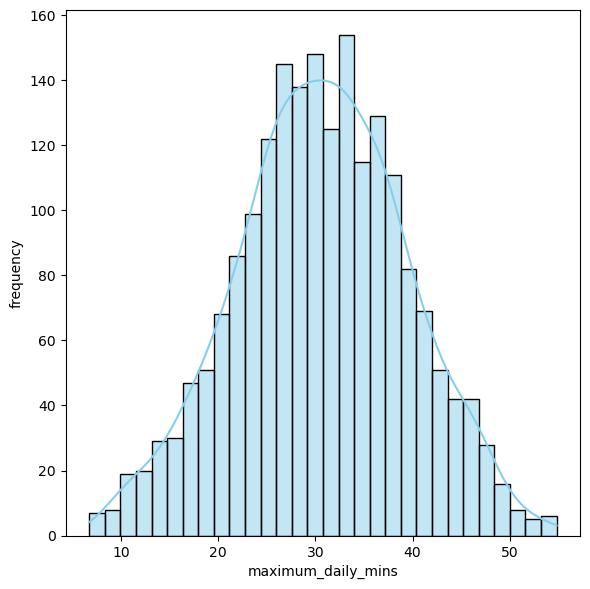

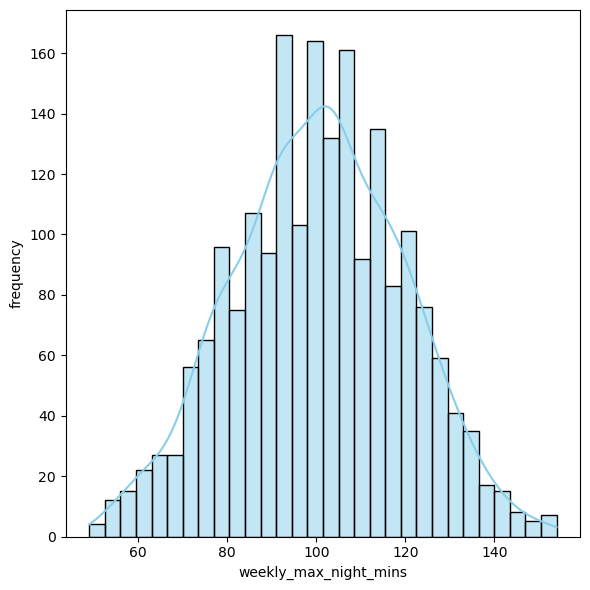

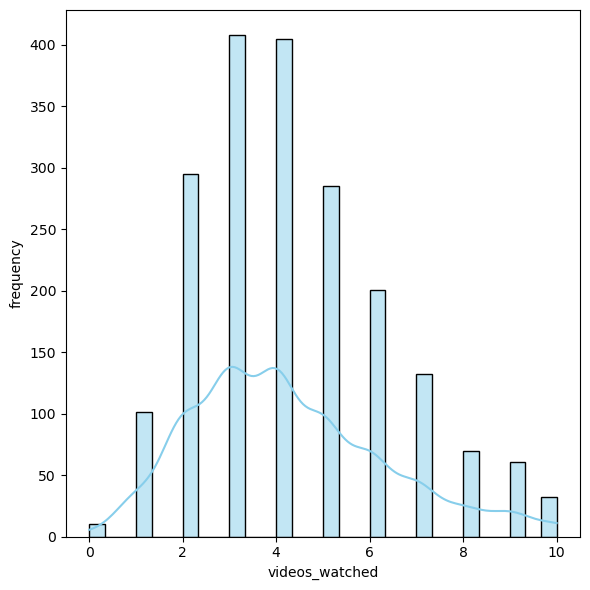

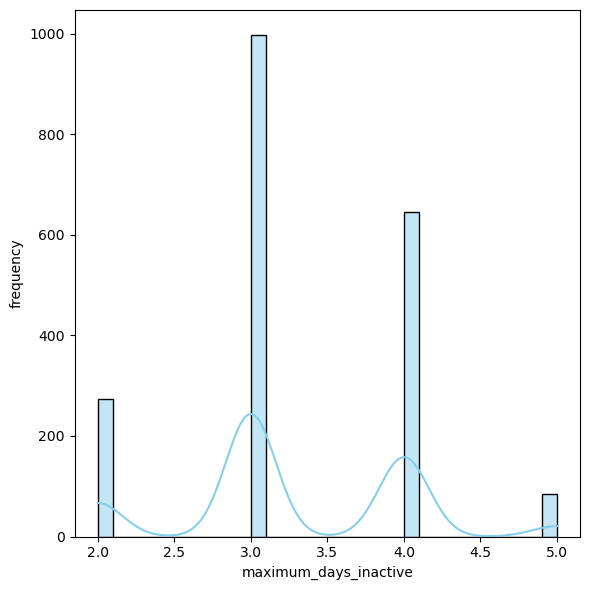

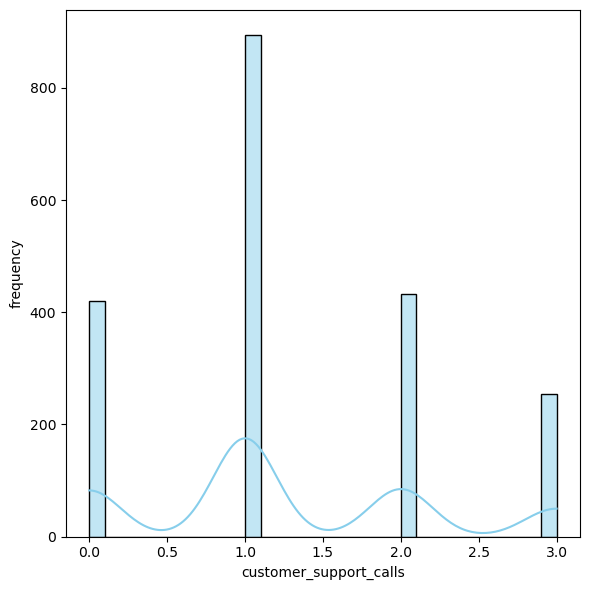

In [16]:
# Histogram
import os
import matplotlib.pyplot as plt
import seaborn as sns

save_folder=r"C:\Users\tarak\Data Files\EDA\Histogram"
os.makedirs(save_folder,exist_ok=True)

for i in num_cols:
    if i == 'churn':
        continue
    plt.figure(figsize=(6,6))
    sns.histplot(churn_df[i],bins=30,color='skyblue',kde=True)
    plt.ylabel('frequency')
    plt.xlabel(i)
    plt.tight_layout()
    plt.savefig(os.path.join(save_folder,f'{i}_histogram.png'))
    plt.show()
    plt.close()

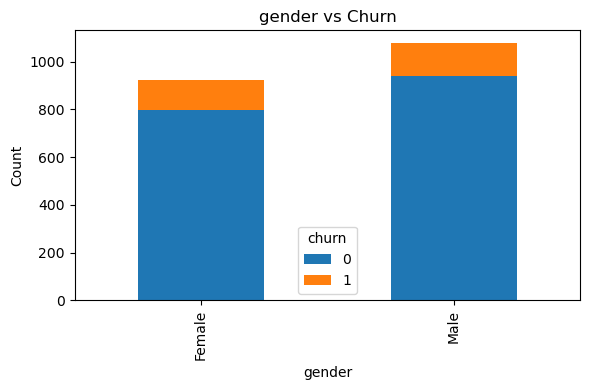

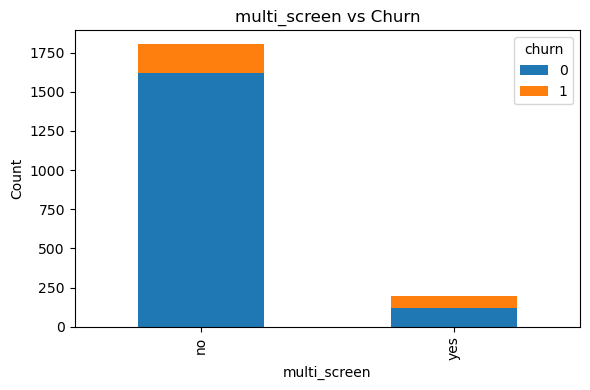

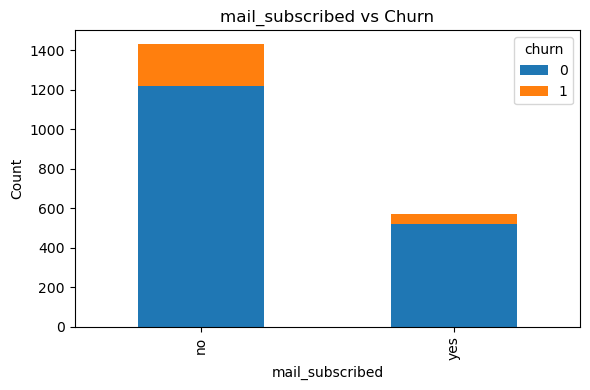

In [17]:
# Categorical vs Churn (Bivariate of categorical columns)

import os
import matplotlib.pyplot as plt
import pandas as pd

save_folder = r"C:\Users\tarak\Data Files\EDA\Bivariate_Categorical"
os.makedirs(save_folder, exist_ok=True)

for i in cat_cols:
    
    # Crosstab
    ct = pd.crosstab(churn_df[i], churn_df['churn'])

    # Plot
    ct.plot(kind='bar', stacked=True, figsize=(6,4))

    plt.title(f'{i} vs Churn')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.tight_layout()

    plt.savefig(os.path.join(save_folder, f'{i}_vs_churn.png'))
    plt.show()
    plt.close()

<Figure size 600x400 with 0 Axes>

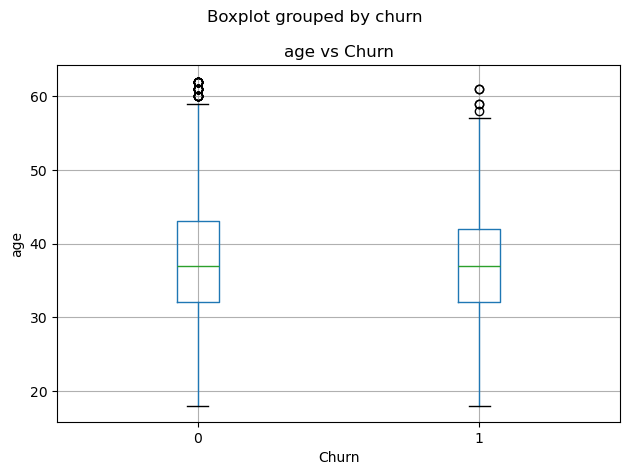

<Figure size 600x400 with 0 Axes>

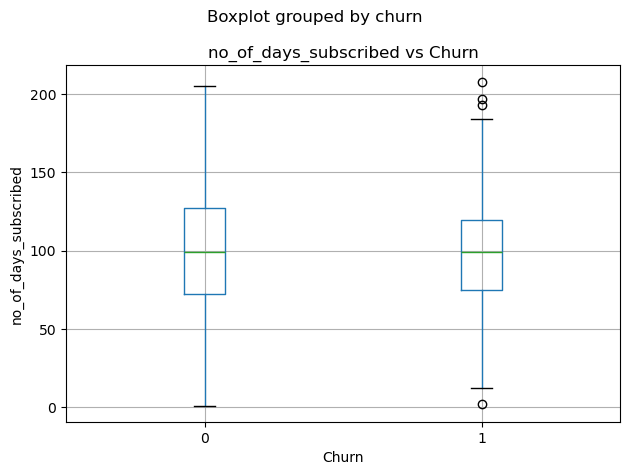

<Figure size 600x400 with 0 Axes>

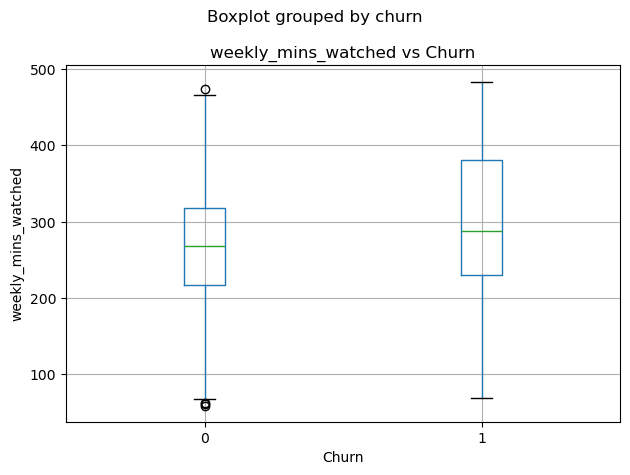

<Figure size 600x400 with 0 Axes>

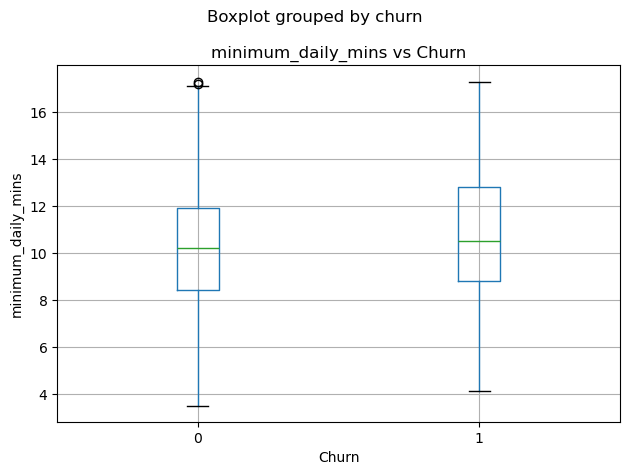

<Figure size 600x400 with 0 Axes>

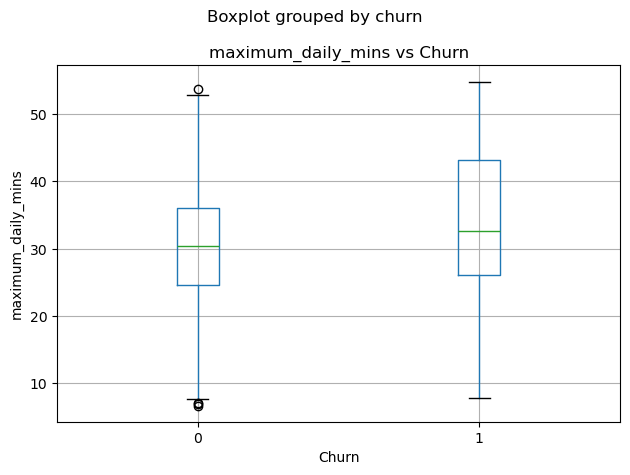

<Figure size 600x400 with 0 Axes>

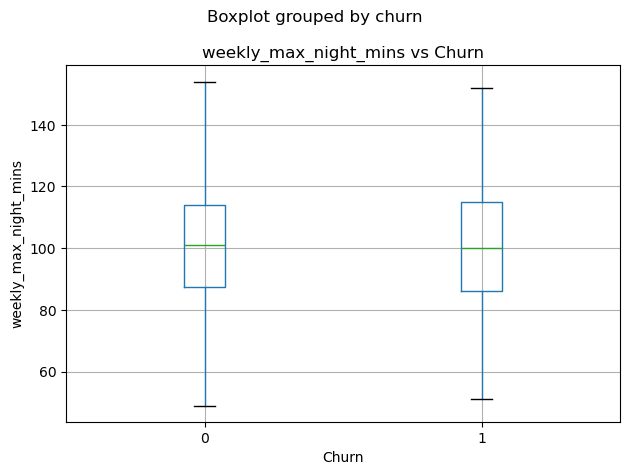

<Figure size 600x400 with 0 Axes>

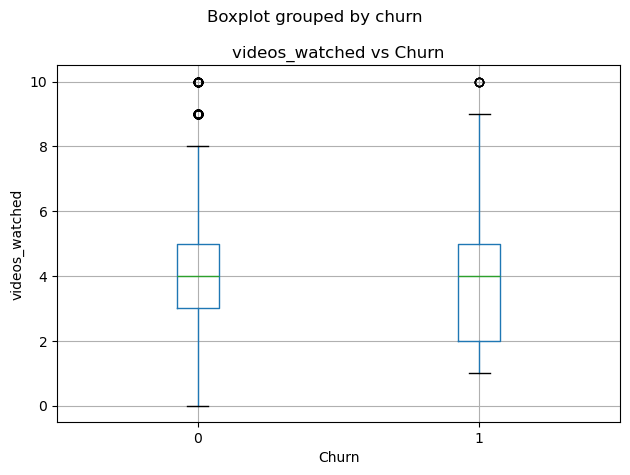

<Figure size 600x400 with 0 Axes>

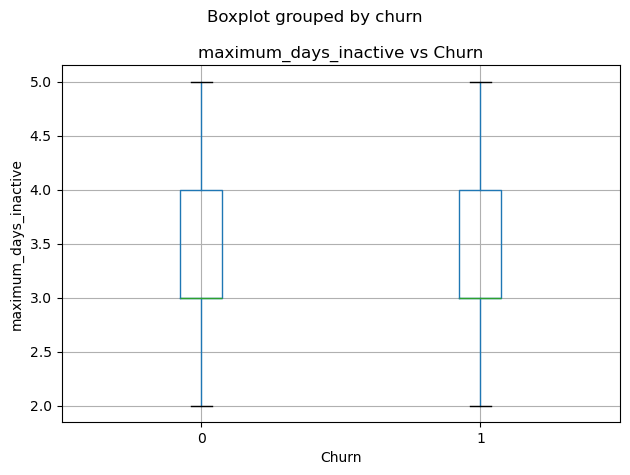

<Figure size 600x400 with 0 Axes>

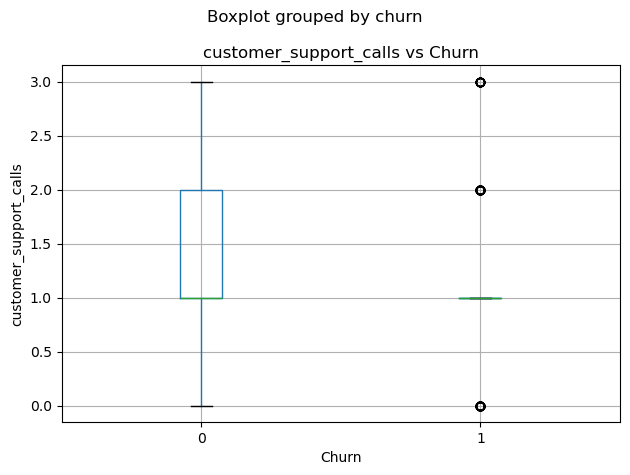

<Figure size 600x400 with 0 Axes>

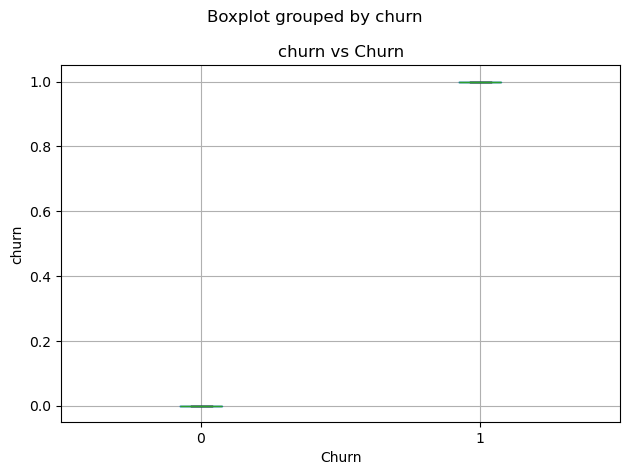

In [18]:
# numerical vs Churn (Bivariate of numerical columns)

import os
import matplotlib.pyplot as plt

save_folder = r"C:\Users\tarak\Data Files\EDA\Bivariate_Numerical"
os.makedirs(save_folder, exist_ok=True)

for i in num_cols:
    
    plt.figure(figsize=(6,4))
    churn_df.boxplot(column=i, by='churn')
    
    plt.title(f'{i} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(i)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(os.path.join(save_folder, f"{i}_vs_churn.png"))
    plt.show()
    plt.close()   # Close the figure to avoid overlap

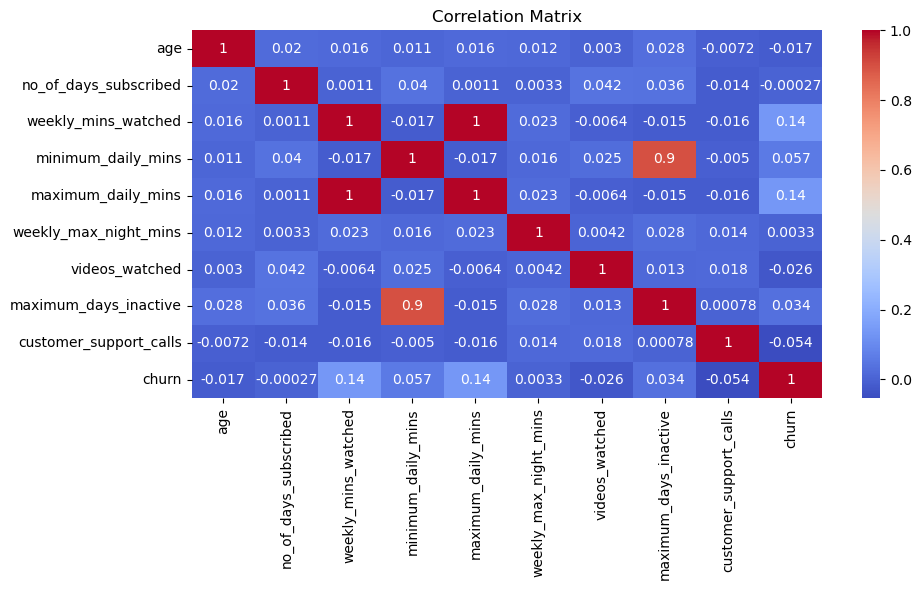

In [19]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

save_folder = r"C:\Users\tarak\Data Files\EDA\Heatmap"
os.makedirs(save_folder, exist_ok=True)

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(churn_df[num_cols].corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.tight_layout()

plt.savefig(os.path.join(save_folder, "correlation_matrix.png"))

plt.show()
plt.close()